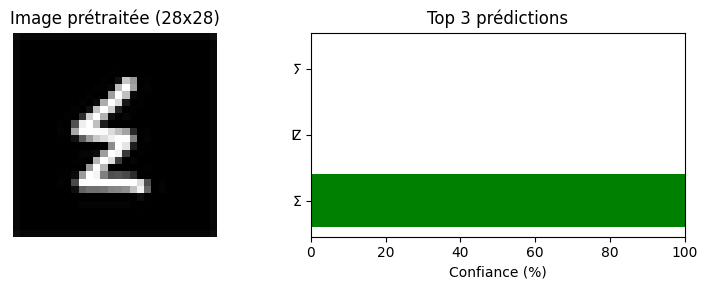


Caractère reconnu : ⵉ
   Confiance         : 100.00%

 Top 3 :
   ⵉ → 100.00%
   ⵇ → 0.00%
   ⵢ → 0.00%


'ⵉ'

In [18]:
from tensorflow.keras.models import load_model
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

model = load_model("../results/models/best_model.h5")

tifinagh_mapping = [
     'ⴰ','ⴱ','ⵛ','ⴷ','ⴻ','ⴼ','ⴳ',
    'ⵀ','ⵉ','ⵊ','ⴽ','ⵍ','ⵎ','ⵏ','ⵇ',
    'ⵔ','ⵙ','ⵜ','ⵓ','ⵡ','ⵢ','ⵅ','ⵣ','ⵃ','ⵚ','ⴹ','ⵟ',
    'ⵄ','ⵖ','ⵥ','ⴳⵯ','ⴽⵯ','ⵕ',
]

def predire_nouvelle_image(image_path):
    """
    Prédit le caractère Tifinagh d'une image extérieure au dataset.
    Gère automatiquement : fond blanc/noir, taille quelconque.
    """
    # Chargement et conversion en niveaux de gris
    img = Image.open(image_path).convert("L")
    
    # Si le fond est blanc (pixel moyen > 127), on inverse
    img_array_check = np.array(img)
    if img_array_check.mean() > 127:
        img = ImageOps.invert(img)
        print("Image inversée (fond blanc détecté → fond noir)")
    
    # Redimensionnement en 28x28
    img = img.resize((28, 28))
    img_array = np.array(img) / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)
    
    # Prédiction
    prediction = model.predict(img_array, verbose=0)
    top3_indices = np.argsort(prediction[0])[::-1][:3]
    
    # Affichage
    plt.figure(figsize=(8, 3))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_array.reshape(28, 28), cmap='gray')
    plt.title("Image prétraitée (28x28)")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    chars  = [tifinagh_mapping[i] for i in top3_indices]
    scores = [prediction[0][i] * 100 for i in top3_indices]
    plt.barh(chars, scores, color=['green', 'orange', 'red'])
    plt.xlabel("Confiance (%)")
    plt.title("Top 3 prédictions")
    plt.xlim(0, 100)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nCaractère reconnu : {tifinagh_mapping[top3_indices[0]]}")
    print(f"   Confiance         : {prediction[0][top3_indices[0]]*100:.2f}%")
    print(f"\n Top 3 :")
    for i in top3_indices:
        print(f"   {tifinagh_mapping[i]} → {prediction[0][i]*100:.2f}%")
    
    return tifinagh_mapping[top3_indices[0]]

import shutil

# Copie une image du dataset dans ton dossier test
shutil.copy("../data/Tifinagh-MNIST-main/Dataset/train_data/8/0_0.png", "../test/test_8.png")

# Teste
predire_nouvelle_image("../test/test_8.png")
# ── Teste avec nouvelle image ──────────────────────────────────
#predire_nouvelle_image("../test/test5.png")  # ← mets ton chemin ici

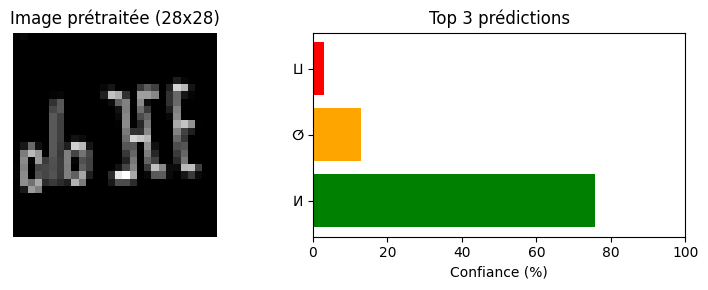


Caractère reconnu : ⵍ
   Confiance         : 75.78%

 Top 3 :
   ⵍ → 75.78%
   ⵚ → 12.92%
   ⵡ → 3.01%


'ⵍ'

In [36]:
# ── Teste avec nouvelle image ──────────────────────────────────
predire_nouvelle_image("../test/mot1.png")  # ← mets ton chemin ici